In [13]:

import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [25]:
tree = {
"name": "Company",
"children": [
{"name": "HR"},
{"name": "Tech", "children": [
{"name": "Backend"},
{"name": "Frontend"},
]}
]}
def print_tree(node, prefix=""):
    print(prefix+ node["name"])
    if "children" in node:
        for child in node["children"]:
            print_tree(child, prefix + " ")
print_tree(tree)

Company
 HR
 Tech
  Backend
  Frontend


# Task 3

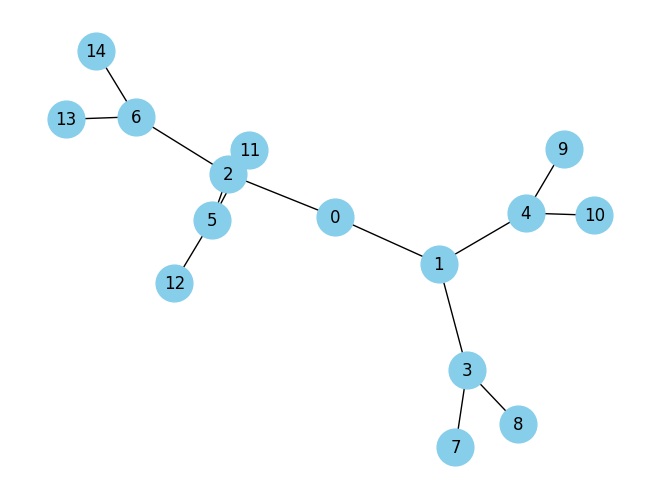

In [9]:
G = nx.balanced_tree(r=2, h=3) # binary tree
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.show()

# Task 4

In [ ]:
import os
from IPython.display import IFrame
import networkx as nx
from pyvis.network import Network

root_dir = r"D:\ThinkPad T480s\Documents"

G = nx.DiGraph()

for folder, subfolders, files in os.walk(root_dir):
    for sub in subfolders:
        G.add_edge(folder, os.path.join(folder, sub))
    for f in files:
        G.add_edge(folder, os.path.join(folder, f))


# Color function
def get_color(node):
    if os.path.isdir(node):
        return "#ADD8E6"   # light blue for folders
    ext = os.path.splitext(node)[1].lower()
    if ext == ".pdf": return "#FF6347"     # red
    if ext == ".docx": return "#32CD32"    # green
    if ext == ".py": return "#FFA500"      # orange
    return "#CDFF44"                        # lime green for others


net = Network(height="750px", width="100%", directed=True, bgcolor="#FFFFFF", font_color="white")
net.barnes_hut()  # force-directed layout (radial-like)

for node in G.nodes():
    net.add_node(node, label=os.path.basename(node) or node, color=get_color(node))

for u, v in G.edges():
    net.add_edge(u, v)



net.write_html("radial_filesystem.html")
IFrame("radial_filesystem.html", width="100%", height="750px")


In [59]:
def hierarchy_pos(G, root=None, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
    if pos is None:
        pos = {}
    children = list(G.successors(root))
    if not isinstance(G, nx.DiGraph):
        raise TypeError("This layout only works for DiGraph.")

    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2
        for child in children:
            nextx += dx
            pos = hierarchy_pos(G, root=child, width=dx, vert_gap=vert_gap,
                                 vert_loc=vert_loc - vert_gap, xcenter=nextx, pos=pos, parent=root)
    pos[root] = (xcenter, vert_loc)
    return pos

# Choose the root (top folder)
root_node = root_dir


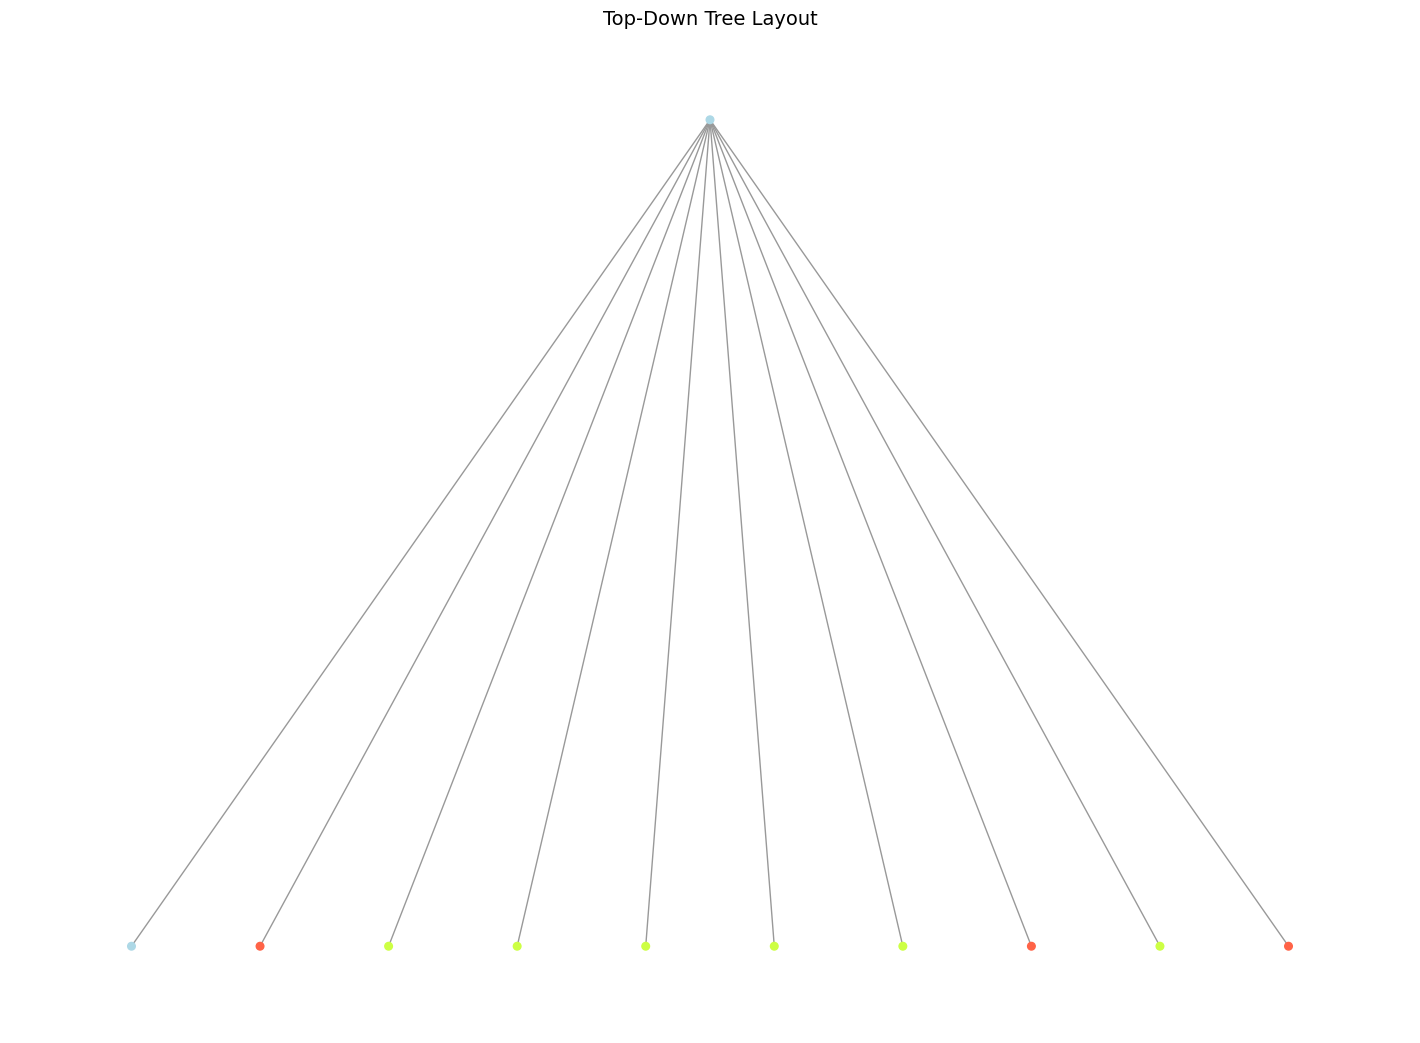

In [61]:
plt.figure(figsize=(14, 10))
pos_tree = hierarchy_pos(G, root=root_node)
nx.draw(
    G, pos_tree,
    with_labels=False,
    node_color=colors,
    node_size=30,
    edge_color="#999999",
    arrows=False
)
plt.title("Top-Down Tree Layout", fontsize=14)
plt.show()


# task 5

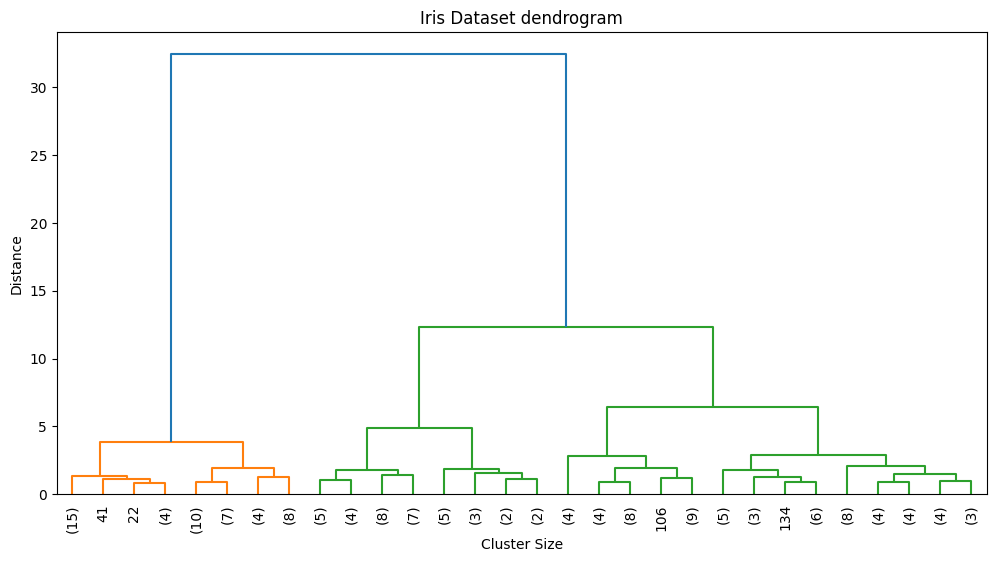

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data  
linked = linkage(X, method='ward')


plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp', 
           p=30,                  
           leaf_rotation=90,
           leaf_font_size=10)
plt.title("Iris Dataset dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


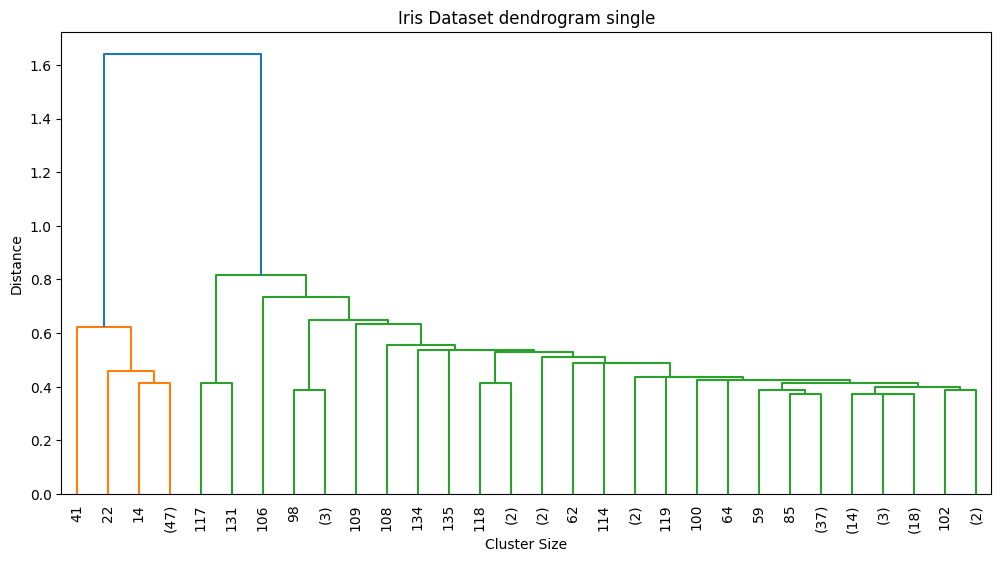

In [ ]:

linked = linkage(X, method='single')


plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',  
           p=30,                  
           leaf_rotation=90,
           leaf_font_size=10)
plt.title("Iris Dataset dendrogram single")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


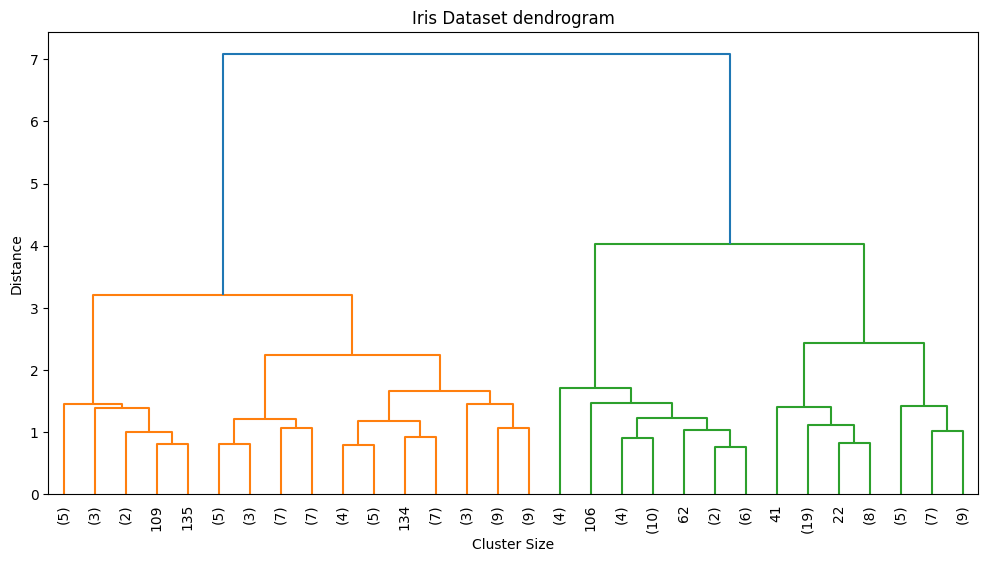

In [ ]:

linked = linkage(X, method='complete')


plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',  
           p=30,                  
           leaf_rotation=90,
           leaf_font_size=10)
plt.title("Iris Dataset dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


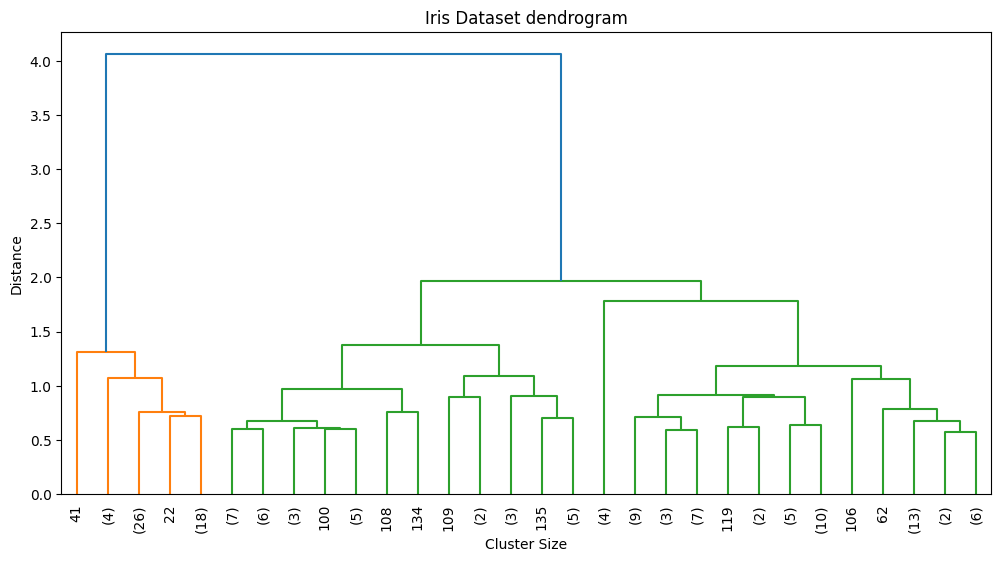

In [ ]:
linked = linkage(X, method='average')


plt.figure(figsize=(12, 6))
dendrogram(linked,
           truncate_mode='lastp',  
           p=30,                  
           leaf_rotation=90,
           leaf_font_size=10)
plt.title("Iris Dataset dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()


# task 6

In [56]:
import plotly.express as px

df = px.data.tips()

fig1 = px.treemap(
    df,
    path=['day', 'time'],
    values='total_bill',
    color='day',
    title="Squarified Layout"
)
fig1.show()


fig2 = px.treemap(
    df,
    path=['day', 'time'],
    values='total_bill',
    color='day',
    title="Slice & Dice Layout"
)
fig2.update_traces(tiling=dict(packing='dice'))
fig2.show()



fig3 = px.treemap(
    df,
    path=['day', 'time'],
    values='total_bill',
    color='day',
    title="Ordered Layout"
)
fig3.update_traces(tiling=dict(packing='binary'))
fig3.show()

# task 7

In [55]:
fig4 = px.sunburst(df, path = ['day', 'time'], values='total_bill', color='day', title="Sunburst Layout")

fig5 = px.icicle(df, path = ['day', 'time'], values='total_bill', color='day', title="Icicle Layout")
fig4.show()
fig5.show()